# Лабораторная работа по математическому анализу

## Численный метод

Прибавкин Андрей M3235

## Графики:

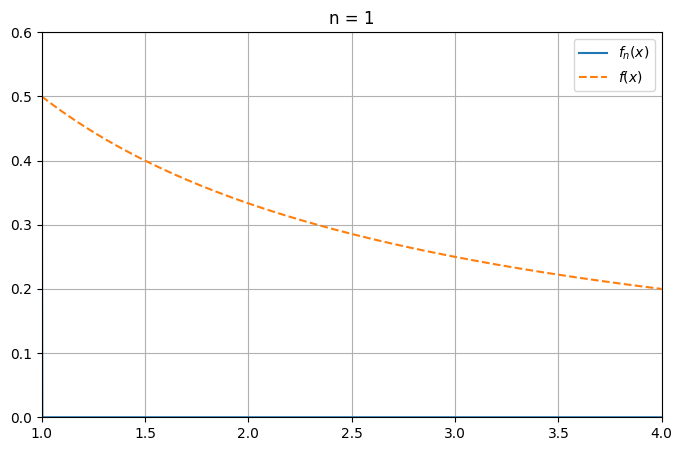

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Исходная функция
def f(x):
    return 1 / (x + 1)

# Последовательность функций
def f_n(x, n):
    return np.floor((2**n) * f(x)) / (2**n)

x = np.linspace(1, 4, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
line_fn, = ax.plot([], [], label='$f_n(x)$')
line_f, = ax.plot(x, f(x), '--', label='$f(x)$')

ax.set_xlim(1, 4)
ax.set_ylim(0, 0.6)
ax.grid(True)
ax.legend()

title = ax.set_title('')

def update(n):
    y = f_n(x, n)
    line_fn.set_data(x, y)
    title.set_text(f'n = {n}')
    return line_fn, title

anim = FuncAnimation(fig, update, frames=range(1, 15), interval=700, blit=False)
HTML(anim.to_jshtml())

## Вычисление интегралов

### Лебега:

$$
\int_1^4 \frac{1}{x+1}\,dx=\ln(x+1)\Big|_1^4=\ln 5-\ln 2=\ln\frac52.
$$

In [10]:
import numpy as np

def f(x):
    return 1 / (x + 1)

def f_n(x, n):
    return np.floor((2**n) * f(x)) / (2**n)

x_grid = np.linspace(1, 4, 200000)
I_exact = np.log(5 / 2)

for n in [10, 100, 1000]:
    I_n = np.trapezoid(f_n(x_grid, n), x_grid)
    print(f"n = {n:4d} | I_n = {I_n:.12f} | analytic = {I_exact:.12f} | error = {abs(I_n - I_exact):.3e}")

n =   10 | I_n = 0.914825658113 | analytic = 0.916290731874 | error = 1.465e-03
n =  100 | I_n = 0.916290731878 | analytic = 0.916290731874 | error = 3.938e-12
n = 1000 | I_n = 0.916290731878 | analytic = 0.916290731874 | error = 3.938e-12


### Лебега-Стилтьеса:

In [15]:
import numpy as np

def f(x):
    return 1 / (x + 1)

def f_n(x, n):
    return np.floor((2**n) * f(x)) / (2**n)

def alpha_prime(x):
    return 4 * x

x_grid = np.linspace(0, 4, 200000)
I_exact = 16 - 4 * np.log(5)

for n in [10, 100, 1000]:
    I_n = np.trapezoid(f_n(x_grid, n) * alpha_prime(x_grid), x_grid)
    print(f"n = {n:4d} | I_n = {I_n:.12f} | analytic = {I_exact:.12f} | error = {abs(I_n - I_exact):.3e}")

n =   10 | I_n = 9.546623817554 | analytic = 9.562248350264 | error = 1.562e-02
n =  100 | I_n = 9.562248350136 | analytic = 9.562248350264 | error = 1.280e-10
n = 1000 | I_n = 9.562248350136 | analytic = 9.562248350264 | error = 1.280e-10
